In [ ]:
import duckdb
import polars as pl
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


In [ ]:
con = duckdb.connect("../data/m5.db")

In [ ]:
!pwd ../data/

/home/njimenez/Workspace/magister/forecast-tfm/data/m5.db

In [ ]:
con.execute("SHOW TABLES").fetchdf()

In [ ]:
!ls ../data/processed/*

In [ ]:
YEAR = 2015

# Sample dataset

In [ ]:
df_sample = con.execute("SELECT * FROM dataset_raw WHERE event_name IS NOT NULL LIMIT 5").fetchdf()

df_sample

In [ ]:
df_sample.head(1).T

In [ ]:
df_jerarquia = con.execute("SELECT dept_id, item_id FROM dataset_raw GROUP BY ALL ORDER BY dept_id, item_id").fetchdf()

In [ ]:
df_jerarquia.groupby("dept_id")['item_id'].agg(['min', 'max', 'count'])

In [ ]:
# Ver qué números específicos faltan en cada departamento
for dept in df_jerarquia['dept_id'].unique():
    ids = df_jerarquia[df_jerarquia['dept_id'] == dept]['item_id'].unique()
    nums = sorted(int(i.split('_')[-1]) for i in ids)
    esperado = set(range(1, max(nums) + 1))
    faltantes = esperado - set(nums)
    if faltantes:
        print(f"{dept}: faltan id items {sorted(faltantes)}")

In [ ]:
con.execute("SELECT * FROM dataset_raw LIMIT 3").fetchdf()

In [ ]:
con.execute("SELECT * FROM dataset_raw WHERE event_name != 'None' LIMIT 5").fetchdf()

# By date

In [ ]:
df_by_date = con.execute(f"""
    SELECT
    date,
    SUM(sales) AS sales
    FROM dataset_raw
    GROUP BY date
    ORDER BY date
""").df()

df_by_date['date'] = pd.to_datetime(df_by_date['date'])
df_by_date = df_by_date.set_index('date').asfreq('D')
# Rolling means de 7, 28 y 364 días
df_by_date['rolling_7'] = df_by_date['sales'].rolling(window=7).mean()
df_by_date['rolling_28'] = df_by_date['sales'].rolling(window=28).mean()
df_by_date['rolling_364'] = df_by_date['sales'].rolling(window=364).mean()

In [ ]:
ts = df_by_date[['sales','rolling_7', 'rolling_28', 'rolling_364']]

fig, ax = plt.subplots(figsize=(12,4))

ax.plot(ts.index, ts['sales'], color='lightgray', linewidth=0.8, label='Ventas diarias')
ax.plot(ts.index, ts['rolling_28'], color='steelblue', linewidth=2, label='Rolling 28d')
ax.plot(ts.index, ts['rolling_364'], color='firebrick', linewidth=2.5, label='Rolling 364d')

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax.set_title("Total de ventas diarias 2011-2016", loc="left", fontsize=14, fontweight="bold", pad=20)
ax.set_xlabel("")
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)

fig.tight_layout()
plt.show()

In [ ]:
ts = df_by_date[['sales','rolling_7', 'rolling_28', 'rolling_364']]

fig, ax = plt.subplots(figsize=(12,4))

ax.plot(ts.index, ts['sales'], color='lightgray', linewidth=0.8, label='Ventas diarias')

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))

train_start = ts.index.min()
train_end = pd.Timestamp('2015-03-27')
valid_end = pd.Timestamp('2016-04-24')
test_end  = pd.Timestamp('2016-05-22')

ax.axvspan(train_start, train_end, color='steelblue', alpha=0.15, label='Train')
ax.axvspan(train_end, valid_end, color='orange', alpha=0.15, label='Validation')
ax.axvspan(valid_end, test_end, color='green', alpha=0.15, label='Test')

ax.axvline(train_end, color='black', linestyle='--', linewidth=1)
ax.axvline(valid_end, color='black', linestyle='--', linewidth=1)

ax.set_title("Total de ventas diarias 2011-2016", loc="left", fontsize=14, fontweight="bold", pad=20)
ax.set_xlabel("")
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)

fig.tight_layout()
plt.show()

In [ ]:
ts = df_by_date[['sales','rolling_7', 'rolling_28', 'rolling_364']].loc['2016-04-25':'2016-05-22']

fig, ax = plt.subplots(figsize=(12,4))

ax.plot(ts.index, ts['sales'], color='blue', linewidth=1.5, label='Ventas diarias')

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax.set_title("Total de ventas diarias: Periodo Test", loc="left", fontsize=14, fontweight="bold", pad=20)
ax.set_xlabel("")
ax.set_xticks(ts.index)
ax.legend(loc="upper left", fontsize=9, frameon=False)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.grid(alpha=0.3)
plt.ylim(0)
plt.show()

plt.ylim(0)
plt.show()

In [ ]:
from statsmodels.tsa.seasonal import STL

stl = STL(ts['sales'].dropna(), period=364, robust=True)
result = stl.fit()

fig = result.plot()
fig.set_size_inches(14, 8)
plt.show()

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(14,6))
plot_acf(ts['sales'].dropna(), lags=400, ax=axes[0])
plot_pacf(ts['sales'].dropna(), lags=60, ax=axes[1])
plt.tight_layout()
plt.show()

# By year

In [ ]:
df_dept_year = con.execute(f"""
    SELECT
        dept_id,
        EXTRACT(YEAR FROM date) AS year,
        SUM(mnt_gross_sales) AS total_gross_sales,
        COUNT(DISTINCT(date)) AS n_days
    FROM dataset_raw
    WHERE date >= '2011-02-01' and date < '2016-05-01'
    GROUP BY 1, 2
    ORDER BY 1, 2
""").df()

df_dept_year['total_gross_sales_pct'] = df_dept_year['total_gross_sales'] / df_dept_year.groupby('year')['total_gross_sales'].transform('sum')
df_dept_year.head()

In [ ]:
df_plot = df_dept_year.pivot(index='dept_id', columns='year', values='total_gross_sales')

plt.figure(figsize=(10, 4))
ax = sns.heatmap(
    df_plot / 1e6, cmap='RdYlGn', annot=True, fmt='.2f', annot_kws={'size': 8},
    linewidths=0.5,
    cbar_kws={'label': 'Millones de $'}
)
plt.title(f'Gross Sales por Departamento y Mes', pad=20, fontsize=12)
plt.xlabel('Mes')
plt.ylabel('Departamento')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
df_store_year = con.execute(f"""
    SELECT
        store_id,
        EXTRACT(YEAR FROM date) AS year,
        SUM(mnt_gross_sales) AS total_gross_sales,
        COUNT(DISTINCT(date)) AS n_days
    FROM dataset_raw
    WHERE date >= '2011-02-01' and date < '2016-05-01'
    GROUP BY 1, 2
    ORDER BY 1, 2
""").df()

df_store_year['total_gross_sales_pct'] = df_store_year['total_gross_sales'] / df_store_year.groupby('year')['total_gross_sales'].transform('sum')
df_store_year.head()

In [ ]:
df_plot = df_store_year.pivot(index='store_id', columns='year', values='total_gross_sales')

plt.figure(figsize=(10, 4))
ax = sns.heatmap(
    df_plot / 1e6, cmap='RdYlGn', annot=True, fmt='.1f', annot_kws={'size': 8},
    linewidths=0.5,
    cbar_kws={'label': 'Millones de $'}
)
plt.title(f'Gross Sales por Sucursal y Mes', pad=20, fontsize=12)
plt.xlabel('Mes')
plt.ylabel('Sucursal')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# By Month

In [ ]:
df_month_year = con.execute(f"""
    SELECT
        EXTRACT(YEAR FROM date) AS year,
        EXTRACT(MONTH FROM date) AS month,
        SUM(mnt_gross_sales) AS total_gross_sales,
        COUNT(DISTINCT(date)) AS n_days
    FROM dataset_raw
    WHERE date >= '2011-02-01' and date < '2016-05-01'
    GROUP BY 1, 2
    ORDER BY 1, 2
""").df()

df_month_year['total_gross_sales_pct'] = df_month_year['total_gross_sales'] / df_month_year.groupby('year')['total_gross_sales'].transform('sum')
df_month_year.head()

In [ ]:
df_plot = df_month_year.pivot(index='year', columns='month', values='total_gross_sales')

plt.figure(figsize=(10, 4))
ax = sns.heatmap(
    df_plot / 1e6, cmap='RdYlGn', annot=True, fmt='.1f', annot_kws={'size': 8},
    linewidths=0.5,
    cbar_kws={'label': 'Millones de $'}
)
plt.title(f'Gross Sales por Año y Mes', pad=20, fontsize=12)
plt.xlabel('Mes')
plt.ylabel('Año')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Dept - Month

In [ ]:
df_dept_month = con.execute(f"""
    SELECT
        dept_id,
        strftime(date, '%Y-%m') AS year_month,
        SUM(mnt_gross_sales) AS total_gross_sales
    FROM dataset_raw
    WHERE date >= '{YEAR}-01-01' AND date < '{YEAR+1}-01-01'
    GROUP BY dept_id, year_month
    ORDER BY dept_id, year_month
""").df()

df_dept_month['total_gross_sales_pct'] = df_dept_month['total_gross_sales'] / df_dept_month.groupby('dept_id')['total_gross_sales'].transform('sum')
df_dept_month

In [ ]:
df_plot = df_dept_month.pivot(index='dept_id', columns='year_month', values='total_gross_sales_pct')

plt.figure(figsize=(10, 4))
ax = sns.heatmap(
    df_plot * 100, cmap='RdYlGn', annot=False, linewidths=0.5,
    cbar_kws={'label': '% de ingresos del departamento'}
)
plt.title(f'Gross Sales por Departamento y Mes ({YEAR})', pad=20, fontsize=12)
plt.xlabel('Mes')
plt.ylabel('Departamento')
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
df_plot = df_dept_month.pivot(index='dept_id', columns='year_month', values='total_gross_sales_pct')

plt.figure(figsize=(10, 4))
ax = sns.heatmap(
    df_plot * 100, cmap='RdYlGn', annot=False, linewidths=0.5,
    cbar_kws={'label': '% de ingresos del departamento'}
)
plt.title(f'Gross Sales por Departamento y Mes ({YEAR})', pad=20, fontsize=12)
plt.xlabel('Mes')
plt.ylabel('Departamento')
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Store - month

In [ ]:
df_store_month = con.execute(f"""
    SELECT
        store_id,
        strftime(date, '%Y-%m') AS year_month,
        SUM(mnt_gross_sales) AS total_gross_sales
    FROM dataset_raw
    WHERE date >= '{YEAR}-01-01' AND date < '{YEAR+1}-01-01'
    GROUP BY store_id, year_month
    ORDER BY store_id, year_month
""").df()

df_store_month['total_gross_sales_pct'] = df_store_month['total_gross_sales'] / df_store_month.groupby('store_id')['total_gross_sales'].transform('sum')

In [ ]:
df_plot = df_store_month.pivot(index='store_id', columns='year_month', values='total_gross_sales_pct')

plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    df_plot * 100,
    cmap='RdYlGn',
    annot=True, fmt='.2f', annot_kws={'size': 8},
    linewidths=0.5,
    cbar_kws={'label': '% de ingresos de la tienda'}
)
plt.title(f'Gross Sales por Tienda y Mes ({YEAR})', pad=20, fontsize=12)
plt.xlabel('Mes')
plt.ylabel('Tienda')
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
df_day_month = con.execute(f"""
    SELECT
        strftime(date, '%d') AS day,
        strftime(date, '%Y-%m') AS year_month,
        SUM(mnt_gross_sales) AS total_gross_sales
    FROM dataset_raw
    WHERE date >= '{YEAR}-01-01' AND date < '{YEAR+1}-01-01'
    GROUP BY strftime(date, '%d'), strftime(date, '%Y-%m')
    ORDER BY year_month, day
""").df()

df_day_month['total_gross_sales_pct'] = (
    df_day_month.groupby('year_month')['total_gross_sales']
    .transform(lambda x: x / x.sum())
)

df_plot = df_day_month.pivot(index='year_month', columns='day', values='total_gross_sales_pct')

plt.figure(figsize=(12, 4))
ax = sns.heatmap(
    df_plot * 100,
    cmap='RdYlGn',
    linewidths=0.5,
    cbar_kws={'label': '% de ingresos de la tienda'}
)
plt.title('Distribución de Gross Sales por Día del Mes', pad=20, fontsize=12)
plt.xlabel('Día del mes')
plt.ylabel('Mes')
plt.tight_layout()
plt.show()

# Day of the week

## Store - DOW

In [ ]:
df_store_dow = con.execute(f"""
    SELECT
        store_id,
        strftime(date, '%a') AS day_of_week,
        SUM(mnt_gross_sales) AS total_gross_sales
    FROM dataset_raw
    WHERE date >= '{YEAR}-01-01' AND date < '{YEAR+1}-01-01'
    GROUP BY store_id, strftime(date, '%a')
    ORDER BY store_id, day_of_week
""").df()

df_store_dow['total_gross_sales_pct'] = (
    df_store_dow.groupby('store_id')['total_gross_sales']
    .transform(lambda x: x / x.sum())
)

dow_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df_plot = df_store_dow.pivot(index='store_id', columns='day_of_week', values='total_gross_sales_pct')
df_plot = df_plot[dow_order]

plt.figure(figsize=(10, 4))
ax = sns.heatmap(
    df_plot * 100,
    cmap='RdYlGn',
    annot=True, fmt='.1f', annot_kws={'size': 8},
    linewidths=0.5,
    cbar_kws={'label': '% de ingresos de la tienda'}
)
plt.title('Ingresos por día de la semana', pad=20, fontsize=12)
plt.xlabel('Día de la semana')
plt.ylabel('Tienda')
plt.yticks(rotation=0)
plt.xticks(rotation=0,)
plt.tight_layout()
plt.show()

# Depts

In [ ]:
df_cat = con.execute(f"""
    SELECT
        cat_id,
        SUM(mnt_gross_sales) AS total_gross_sales
    FROM dataset_raw
    WHERE date >= '{YEAR}-01-01' AND date < '{YEAR+1}-01-01'
    GROUP BY 1
    ORDER BY 1
""").df()

df_cat['total_gross_sales_pct'] = df_cat['total_gross_sales'] / df_cat['total_gross_sales'].sum()

df_cat_sorted = df_cat.sort_values('total_gross_sales_pct', ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(df_cat_sorted['cat_id'], df_cat_sorted['total_gross_sales_pct'] * 100, color='#4C72B0')
plt.bar_label(bars, fmt='%.1f%%', padding=3)
plt.xlabel('% del total de ventas')
plt.ylabel('Departamento')
plt.title(f'Distribución de ventas brutas por categoría ({YEAR})', loc='left', pad=15, fontsize=12)
plt.xlim(0, df_cat_sorted['total_gross_sales_pct'].max() * 100 * 1.15)  # deja espacio extra para el label
plt.tight_layout()
plt.show()

In [ ]:
df_dept = con.execute(f"""
    SELECT
        dept_id,
        SUM(mnt_gross_sales) AS total_gross_sales
    FROM dataset_raw
    WHERE date >= '{YEAR}-01-01' AND date < '{YEAR+1}-01-01'
    GROUP BY 1
    ORDER BY 1
""").df()

df_dept['total_gross_sales_pct'] = df_dept['total_gross_sales'] / df_dept['total_gross_sales'].sum()

df_dept_sorted = df_dept.sort_values('total_gross_sales_pct', ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(df_dept_sorted['dept_id'], df_dept_sorted['total_gross_sales_pct'] * 100, color='#4C72B0')
plt.bar_label(bars, fmt='%.1f%%', padding=3)
plt.xlabel('% del total de ventas')
plt.ylabel('Departamento')
plt.title(f'Distribución de ventas brutas por departamento ({YEAR})', loc='left', pad=15, fontsize=12)
plt.xlim(0, df_dept_sorted['total_gross_sales_pct'].max() * 100 * 1.15)  # deja espacio extra para el label
plt.tight_layout()
plt.show()

In [ ]:
df_state = con.execute(f"""
    SELECT
        state_id,
        SUM(mnt_gross_sales) AS total_gross_sales
    FROM dataset_raw
    WHERE date >= '{YEAR}-01-01' AND date < '{YEAR+1}-01-01'
    GROUP BY 1
    ORDER BY 1
""").df()

df_state['total_gross_sales_pct'] = df_state['total_gross_sales'] / df_state['total_gross_sales'].sum()

df_state_sorted = df_state.sort_values('total_gross_sales_pct', ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(df_state_sorted['state_id'], df_state_sorted['total_gross_sales_pct'] * 100, color='#4C72B0')
plt.bar_label(bars, fmt='%.0f%%', padding=3)
plt.xlabel('% del total de ventas')
plt.ylabel('Estado')
plt.title(f'Distribución de ventas brutas por estado ({YEAR})', loc='left', pad=15, fontsize=12)
plt.xlim(0, df_state_sorted['total_gross_sales_pct'].max() * 100 * 1.15)
plt.tight_layout()
plt.show()

In [ ]:
df_store = con.execute(f"""
    SELECT
        state_id,
        store_id,
        SUM(mnt_gross_sales) AS total_gross_sales
    FROM dataset_raw
    WHERE date >= '{YEAR}-01-01' AND date < '{YEAR+1}-01-01'
    GROUP BY 1,2
    ORDER BY 1,2
""").df()

df_store['total_gross_sales_pct'] = df_store['total_gross_sales'] / df_store['total_gross_sales'].sum()

df_store_sorted = df_store.sort_values('total_gross_sales_pct', ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(df_store_sorted['store_id'], df_store_sorted['total_gross_sales_pct'] * 100, color='#4C72B0')
plt.bar_label(bars, fmt='%.1f%%', padding=3)
plt.xlabel('% del total de ventas')
plt.ylabel('Tienda')
plt.title(f'Distribución de ventas brutas por tienda ({YEAR})', loc='left', pad=15, fontsize=12)
plt.xlim(0, df_store_sorted['total_gross_sales_pct'].max() * 100 * 1.15)
plt.tight_layout()
plt.show()

In [ ]:
df_store.to_clipboard(index=False, sep='\t', decimal=',')

# Niveles de agregación

In [ ]:
!ls ../data/processed/

In [ ]:
import os

dir = "../data/processed/daily/"
levels = os.listdir(dir)
levels.sort()
levels

In [ ]:
duckdb.sql('')

In [ ]:
df_level_stats = pd.DataFrame()

for level in levels:
    path = dir + level
    partes = level.split(sep='_')
    level_label = partes[0] + "_" + partes[1]
    df_level = duckdb.sql(
        f"""
        SELECT
            COUNT(DISTINCT(state_id)) AS n_states,
            COUNT(DISTINCT(store_id)) AS n_stores,
            COUNT(DISTINCT(cat_id)) AS n_cat,
            COUNT(DISTINCT(dept_id)) AS n_dept,
            COUNT(DISTINCT(item_id)) AS n_items,
            COUNT(DISTINCT(agg_id)) AS n_series,
            COUNT(DISTINCT(date)) AS ndays,
            COUNT(*) AS n_rows
        FROM '{path}'
        """
    ).fetchdf()
    df_level['level'] = level_label
    df_level = df_level.set_index('level')
    df_level_stats = pd.concat([df_level_stats, df_level])

df_level_stats[['n_cat','n_dept','n_states','n_stores', 'n_items']] = df_level_stats[['n_cat','n_dept','n_states','n_stores', 'n_items']].replace(1, np.nan)

df_level_stats.to_clipboard(index=False)
df_level_stats

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))

sns.lineplot(data=df_level_stats, x=df_level_stats.index, y='n_rows', label='n_rows', ax=ax)
sns.lineplot(data=df_level_stats, x=df_level_stats.index, y='n_series', label='n_series', ax=ax)

ax.set_yscale('log')
ax.set_title('Volumen de registros por nivel de agregación')
plt.xticks(rotation=90)
plt.ylabel('cantidad (log)')
plt.xlabel('')
plt.legend()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))

sns.lineplot(data=df_level_stats, x=df_level_stats.index, y='n_rows', label='n_rows', ax=ax)
sns.lineplot(data=df_level_stats, x=df_level_stats.index, y='n_series', label='n_series', ax=ax)

ax.set_title('Volumen de registros por nivel de agregación')
plt.xticks(rotation=90)
plt.ylabel('cantidad')
plt.xlabel('')
plt.legend()
plt.show()

# Objetivos

In [ ]:
!ls ../data/datasets/*

In [ ]:
FILE = "../data/datasets/daily/dataset_level_01_daily_total.parquet"

df = con.execute(f"""
    SELECT *
    FROM '{FILE}'
    WHERE date >= '2015-01-01' AND date < '2016-01-01'
""").fetchdf()

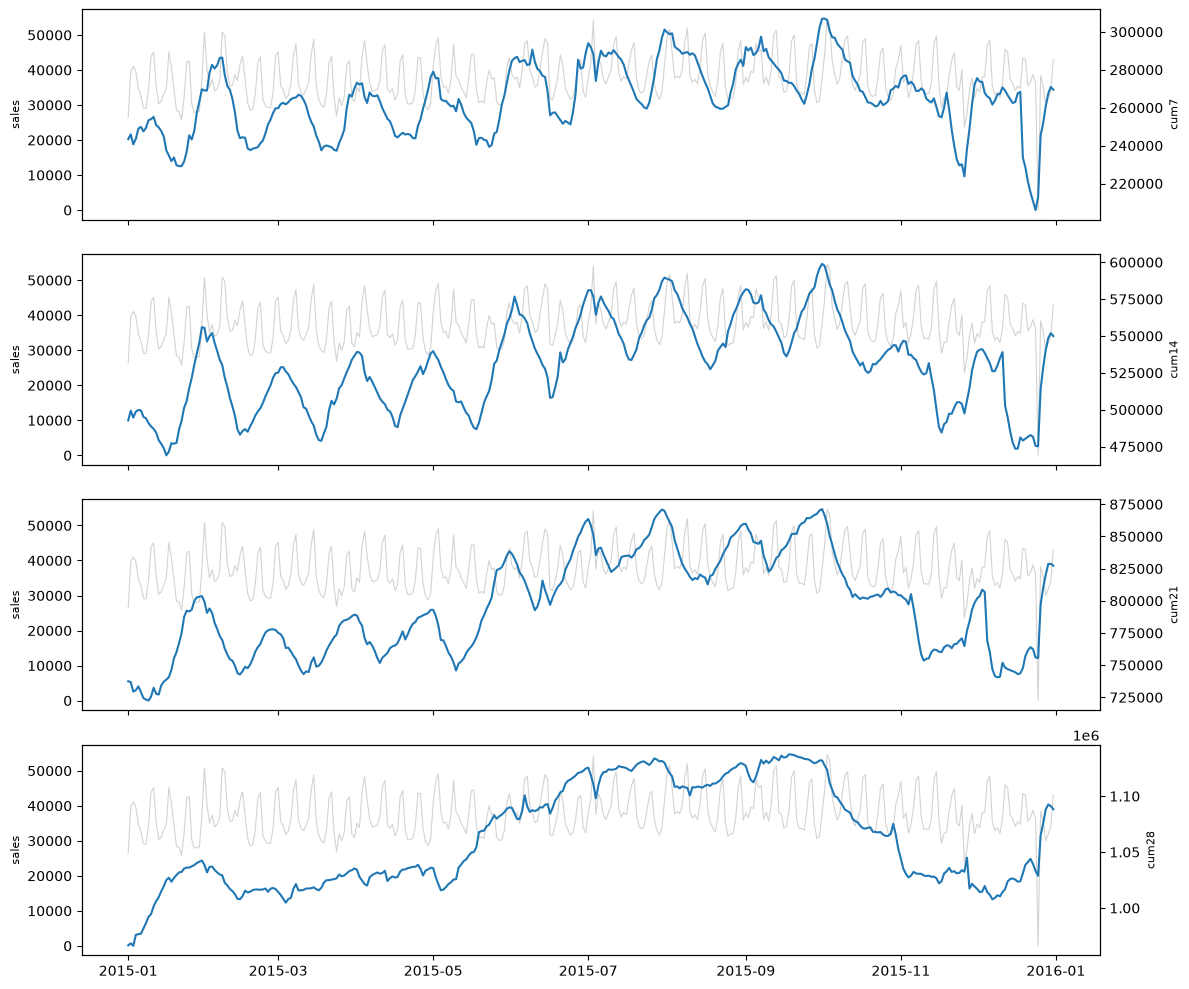

In [84]:
cols_cum = ['cum7', 'cum14', 'cum21', 'cum28']

fig, axes = plt.subplots(len(cols_cum), 1, figsize=(12, 2.5*len(cols_cum)), sharex=True)

for ax, col in zip(axes, cols_cum):
    ax.plot(df_sample['date'], df_sample['sales'], color='lightgray', linewidth=0.8, label='sales')
    ax2 = ax.twinx()
    ax2.plot(df_sample['date'], df_sample[col], color='tab:blue', label=col)
    ax.set_ylabel('sales', fontsize=8)
    ax2.set_ylabel(col, fontsize=8)

fig.tight_layout()
plt.show()

# Demanda